In [246]:
from __future__ import annotations
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_moons, make_classification, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, f1_score, recall_score
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns
import pandas as pd
import sys

sys.path.append('..')
from evaluation_functions import print_metrics, plot_decision_boundary, plot_roc, plot_confusion_matrix, measure_fit_time, ClassifierAbstraction

# Preparing synthetic data

In [247]:
RANDOM_STATE = 264034
N_SAMPLES = 2634

[0 1 2 3]


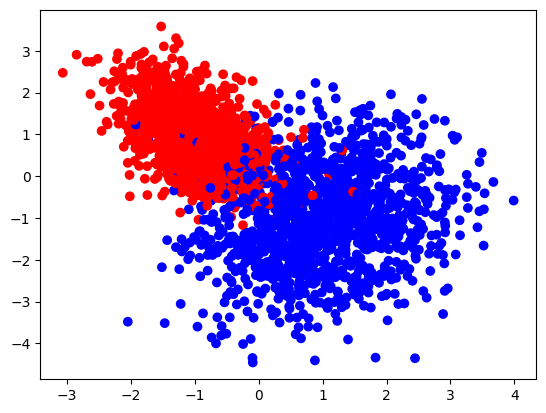

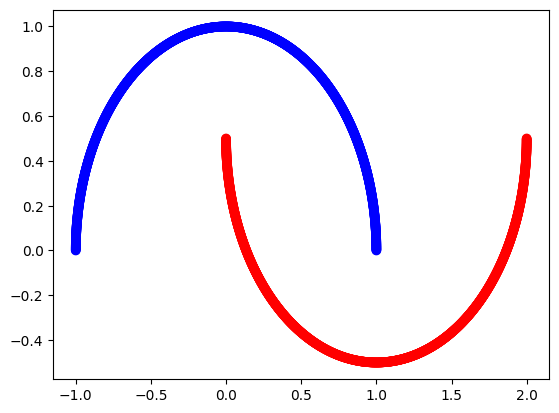

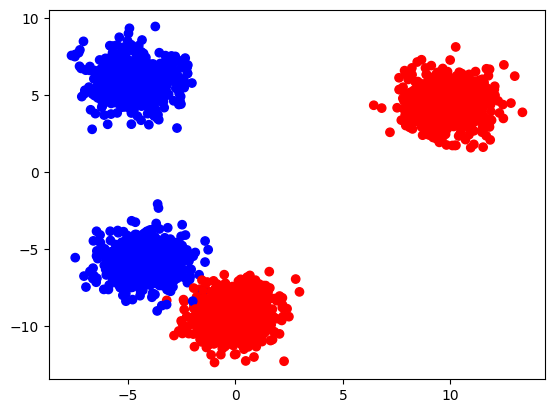

In [248]:
X_classification, y_classification = make_classification(n_samples = N_SAMPLES, n_clusters_per_class=1, n_features = 2, n_redundant = 0, n_informative = 2, random_state = RANDOM_STATE)
X_moons, y_moons = make_moons(n_samples = N_SAMPLES, random_state = RANDOM_STATE, noise=0)
X_multi_claster, y_multi_claster = make_blobs(n_samples = N_SAMPLES, random_state = RANDOM_STATE, n_features=2, centers=4) # type: ignore

print(np.unique(y_multi_claster))
y_multi_claster = np.where( y_multi_claster > 1 , 1, 0)

plt.scatter(X_classification[:, 0], X_classification[:, 1], c=y_classification, cmap="bwr")
plt.show()
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap="bwr")
plt.show()
plt.scatter(X_multi_claster[:,0], X_multi_claster[:,1], c=y_multi_claster, cmap="bwr")
plt.show()

________

# Implementation of decision tree

In [249]:
def entropy(Y : np.ndarray):
    n_samples = len(Y)
    _, classes_counts = np.unique(Y, return_counts=True)
    probabilities = classes_counts / n_samples
    entropy = -np.sum(probabilities * np.log(probabilities))
    return entropy
        

def split_info_gain(Y : np.ndarray, left_mask : np.ndarray):
    right_mask = np.logical_not(left_mask)
    n = len(Y)
    n_left, n_right = left_mask.sum(), right_mask.sum()

    if n_left == 0 or n_right == 0:
        return 0.0

    gain = entropy(Y)
    gain -= (n_left / n) * entropy(Y[left_mask])
    gain -= (n_right / n) * entropy(Y[right_mask])
    return gain


def best_split(X : np.ndarray, Y : np.ndarray, n_percentiles = 20):
    n_sample, n_features = X.shape
    best_gain = -np.inf
    best_feature, best_threshold = None, None

    for feature_idx in range(n_features):
        col = X[:, feature_idx]
        thresholds = np.percentile(col, np.linspace(0, 100, n_percentiles + 2)[1:-1])

        for threshold in thresholds:
            left_mask = X[:, feature_idx] <= threshold
            gain = split_info_gain(Y, left_mask)

            if gain > best_gain:
                best_gain = gain
                best_feature = feature_idx
                best_threshold = threshold

    return best_feature, best_threshold, best_gain

y = np.array([1,1,1,1,1,1,0])
entropy(y)

np.float64(0.410116318288409)

In [250]:
@dataclass
class Node:
    is_leaf: bool = False
    prediction: int | None = None
    feature: int | None = None
    threshold: float | None = None
    left_child: Node | None = None
    right_child: Node | None = None


In [251]:
class DecisionTree(ClassifierAbstraction):
    def __init__(self, max_depth : int | None = None, n_percentiles : int = 20) -> None:
        self.max_depth = max_depth
        self.n_percentiles = n_percentiles
        self.root = None

    def _majority(self, y: np.ndarray) -> int:
        return int(np.bincount(y).argmax())

    def _build(self, X: np.ndarray, y: np.ndarray, depth: int) -> Node:
        if len(np.unique(y)) == 1 or (self.max_depth is not None and depth >= self.max_depth):
            return Node(is_leaf=True, prediction=self._majority(y))
        
        feature, threshold, gain = best_split(X, y, self.n_percentiles)

        if gain <= 0 or feature is None:
            return Node(is_leaf=True, prediction=self._majority(y))

        mask = X[:, feature] <= threshold
        bitwise_not_mask = np.logical_not(mask)
        return Node(
            feature=feature, threshold=threshold,
            left_child=self._build(X[mask], y[mask], depth=depth+1),
            right_child=self._build(X[bitwise_not_mask], y[bitwise_not_mask], depth=depth+1)
        )

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        self.root = self._build(X, y.astype(int), depth=0)

    def _traverse(self, x: np.ndarray, node: Node | None) -> int:
        if node is None:
            return 0
        if node.is_leaf and node.prediction is not None:
            return node.prediction
        if x[node.feature] <= node.threshold:
            return self._traverse(x, node.left_child)
        return self._traverse(x, node.right_child)

    def predict(self, X: np.ndarray) -> np.ndarray:
        return np.array([self._traverse(x, self.root) for x in X])

    def decision_function(self, X: np.ndarray) -> np.ndarray:
        return self.predict(X).astype(float)
    


___________

# Testing on synthetic data

## Fit time

In [252]:
my_dtc = DecisionTree()
sk_dtc = DecisionTreeClassifier(criterion="entropy", random_state=RANDOM_STATE)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_classification, y_classification, test_size=0.3, random_state=RANDOM_STATE)

print(f"Sklearn DTC mean fit time for 100 runs:  {measure_fit_time(sk_dtc, X_train_clf, y_train_clf)}")
print(f"My DTC mean fit time for 100 runs:       {measure_fit_time(my_dtc, X_train_clf, y_train_clf)}")

Sklearn DTC mean fit time for 100 runs:  0.002740648011676967
My DTC mean fit time for 100 runs:       0.18390756201464684


## Moons dataset

____________________________________

── My DTC ──
Confusion matrix:
[[396   0]
 [  0 395]]
Accuracy:       1.0
Recall:         1.0
Specificity:    1.0

── Sklearn DTC ──
Confusion matrix:
[[396   0]
 [  0 395]]
Accuracy:       1.0
Recall:         1.0
Specificity:    1.0


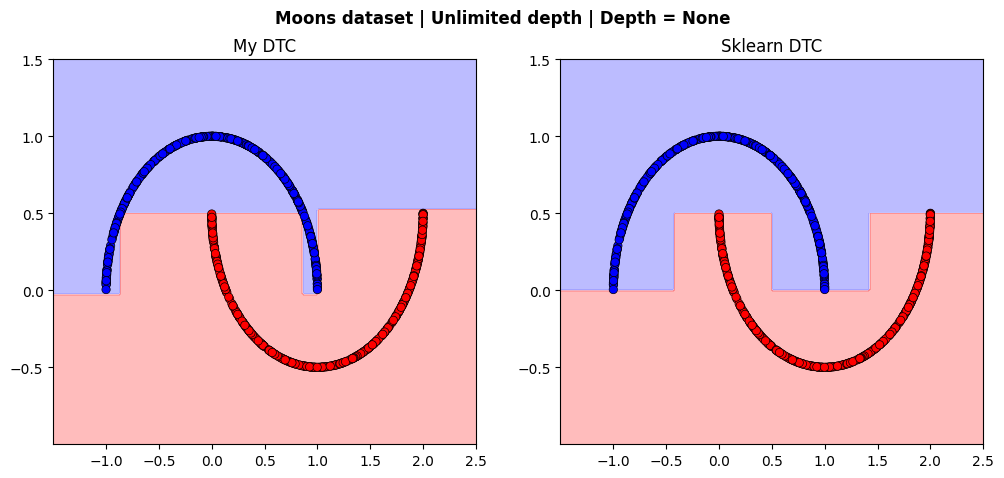

____________________________________

── My DTC ──
Confusion matrix:
[[396   0]
 [154 241]]
Accuracy:       0.8053097345132744
Recall:         0.610126582278481
Specificity:    1.0

── Sklearn DTC ──
Confusion matrix:
[[396   0]
 [147 248]]
Accuracy:       0.8141592920353983
Recall:         0.6278481012658228
Specificity:    1.0


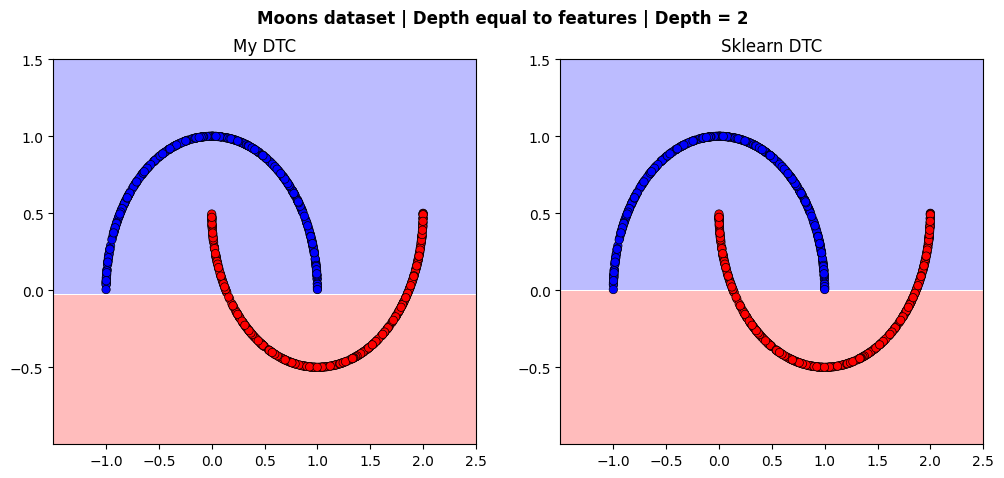

____________________________________

── My DTC ──
Confusion matrix:
[[396   0]
 [154 241]]
Accuracy:       0.8053097345132744
Recall:         0.610126582278481
Specificity:    1.0

── Sklearn DTC ──
Confusion matrix:
[[396   0]
 [147 248]]
Accuracy:       0.8141592920353983
Recall:         0.6278481012658228
Specificity:    1.0


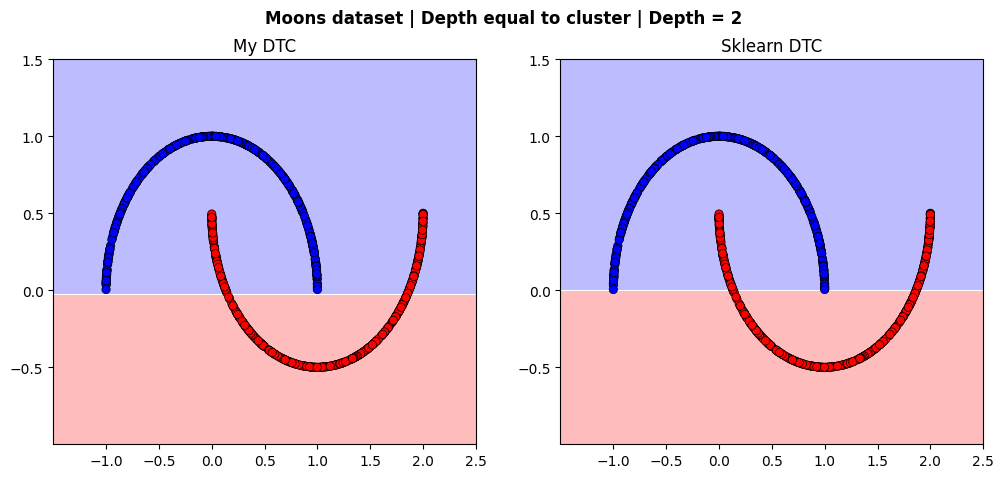

In [253]:
X_train_moons, X_test_moons, y_train_moons, y_test_moons = train_test_split(
    X_moons, y_moons, test_size=0.3, random_state=RANDOM_STATE, stratify=y_moons)

n_features = X_moons.shape[1]
n_cluster = 2
depths_to_test = [None, n_features, n_cluster] # ulimited, number of features, total number of clusters
titles = ["Unlimited depth", "Depth equal to features", "Depth equal to cluster"]

for depth, title in zip(depths_to_test, titles):
    print("____________________________________")
    my_dtc = DecisionTree(depth)
    sk_dtc = DecisionTreeClassifier(max_depth=depth, criterion="entropy")

    my_dtc.fit(X_train_moons, y_train_moons)
    sk_dtc.fit(X_train_moons, y_train_moons)

    print_metrics(my_dtc, X_test_moons, y_test_moons, "My DTC")
    print_metrics(sk_dtc, X_test_moons, y_test_moons, "Sklearn DTC")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"Moons dataset | {title} | Depth = {depth}", fontweight="bold")
    plot_decision_boundary(my_dtc, X_test_moons, y_test_moons, axes[0], "My DTC")
    plot_decision_boundary(sk_dtc, X_test_moons, y_test_moons, axes[1], "Sklearn DTC")
    plt.show()

## Classification dataset

____________________________________

── My DTC ──
Confusion matrix:
[[359  37]
 [ 30 365]]
Accuracy:       0.9152970922882427
Recall:         0.9240506329113924
Specificity:    0.9065656565656566

── Sklearn DTC ──
Confusion matrix:
[[367  29]
 [ 26 369]]
Accuracy:       0.9304677623261695
Recall:         0.9341772151898734
Specificity:    0.9267676767676768


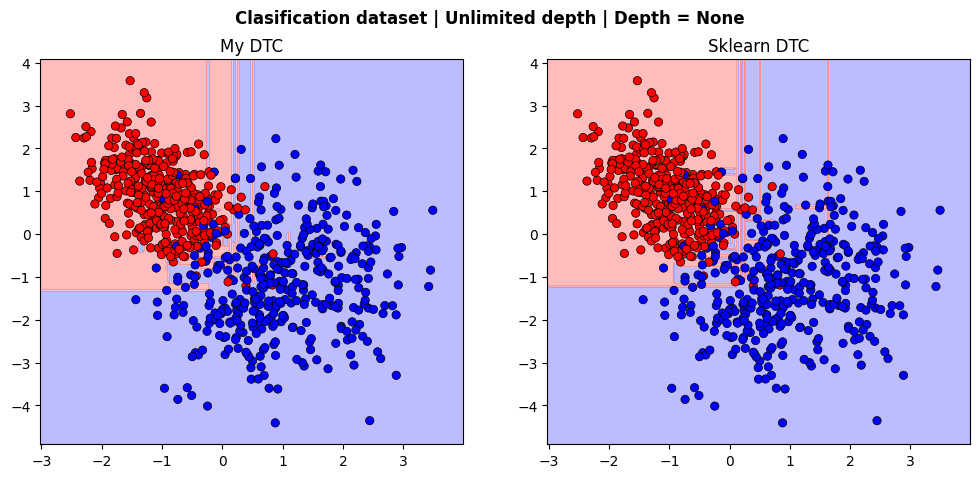

____________________________________

── My DTC ──
Confusion matrix:
[[376  20]
 [ 22 373]]
Accuracy:       0.9469026548672567
Recall:         0.9443037974683545
Specificity:    0.9494949494949495

── Sklearn DTC ──
Confusion matrix:
[[371  25]
 [ 13 382]]
Accuracy:       0.9519595448798989
Recall:         0.9670886075949368
Specificity:    0.9368686868686869


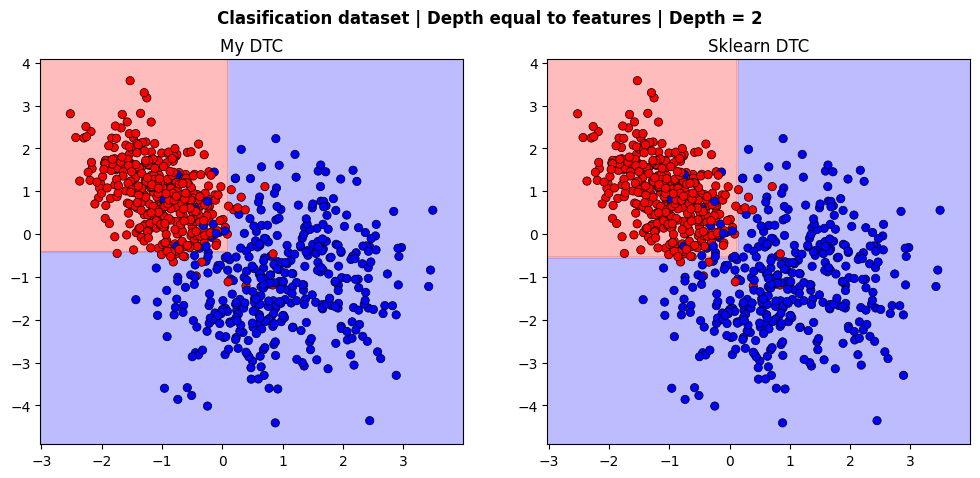

____________________________________

── My DTC ──
Confusion matrix:
[[376  20]
 [ 22 373]]
Accuracy:       0.9469026548672567
Recall:         0.9443037974683545
Specificity:    0.9494949494949495

── Sklearn DTC ──
Confusion matrix:
[[371  25]
 [ 13 382]]
Accuracy:       0.9519595448798989
Recall:         0.9670886075949368
Specificity:    0.9368686868686869


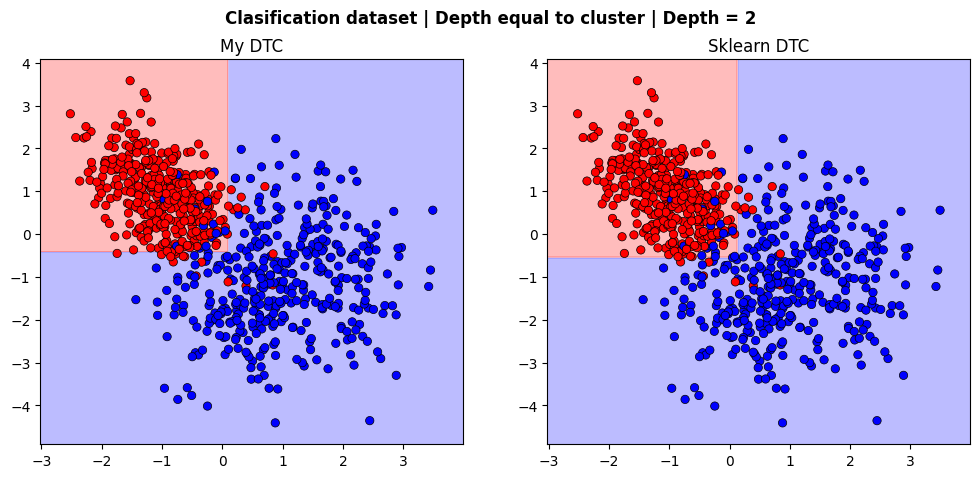

In [254]:
my_dtc = DecisionTree(5)
sk_dtc = DecisionTreeClassifier(max_depth=5)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_classification, y_classification, test_size=0.3, random_state=RANDOM_STATE, stratify= y_classification)

n_features = X_classification.shape[1]
n_cluster = 2
depths_to_test = [None, n_features, n_cluster] # ulimited, number of features, total number of clusters
titles = ["Unlimited depth", "Depth equal to features", "Depth equal to cluster"]

for depth, title in zip(depths_to_test, titles):
    print("____________________________________")
    my_dtc = DecisionTree(depth)
    sk_dtc = DecisionTreeClassifier(max_depth=depth, criterion="entropy")

    my_dtc.fit(X_train_clf, y_train_clf)
    sk_dtc.fit(X_train_clf, y_train_clf)

    print_metrics(my_dtc, X_test_clf, y_test_clf, "My DTC")
    print_metrics(sk_dtc, X_test_clf, y_test_clf, "Sklearn DTC")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"Clasification dataset | {title} | Depth = {depth}", fontweight="bold")
    plot_decision_boundary(my_dtc, X_test_clf, y_test_clf, axes[0], f"My DTC")
    plot_decision_boundary(sk_dtc, X_test_clf, y_test_clf, axes[1], f"Sklearn DTC")
    plt.show()

## Blobs dataset

____________________________________

── My DTC for depth None  ──
Confusion matrix:
[[394   2]
 [  3 392]]
Accuracy:       0.9936788874841972
Recall:         0.9924050632911392
Specificity:    0.9949494949494949

── Sklearn DTC for depth None ──
Confusion matrix:
[[394   2]
 [  1 394]]
Accuracy:       0.9962073324905183
Recall:         0.9974683544303797
Specificity:    0.9949494949494949


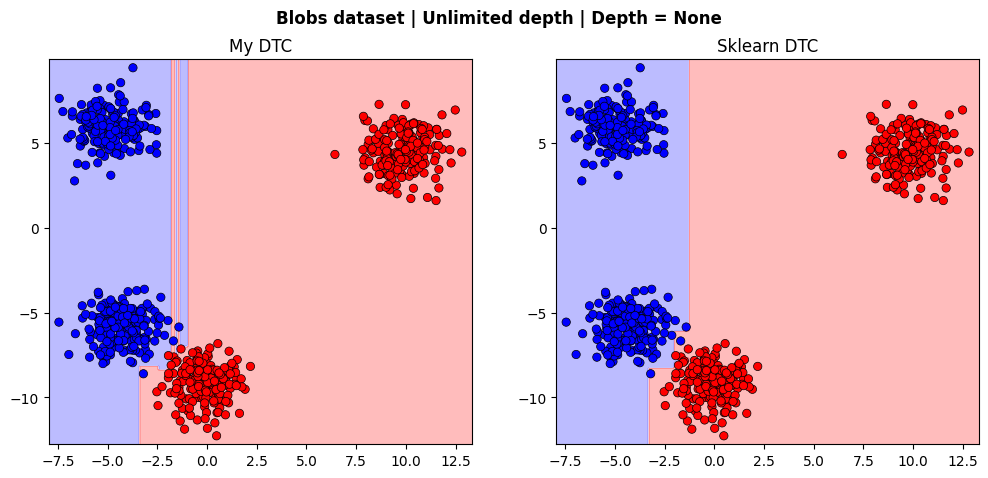

____________________________________

── My DTC for depth 2  ──
Confusion matrix:
[[394   2]
 [  5 390]]
Accuracy:       0.9911504424778761
Recall:         0.9873417721518988
Specificity:    0.9949494949494949

── Sklearn DTC for depth 2 ──
Confusion matrix:
[[392   4]
 [  0 395]]
Accuracy:       0.9949431099873578
Recall:         1.0
Specificity:    0.98989898989899


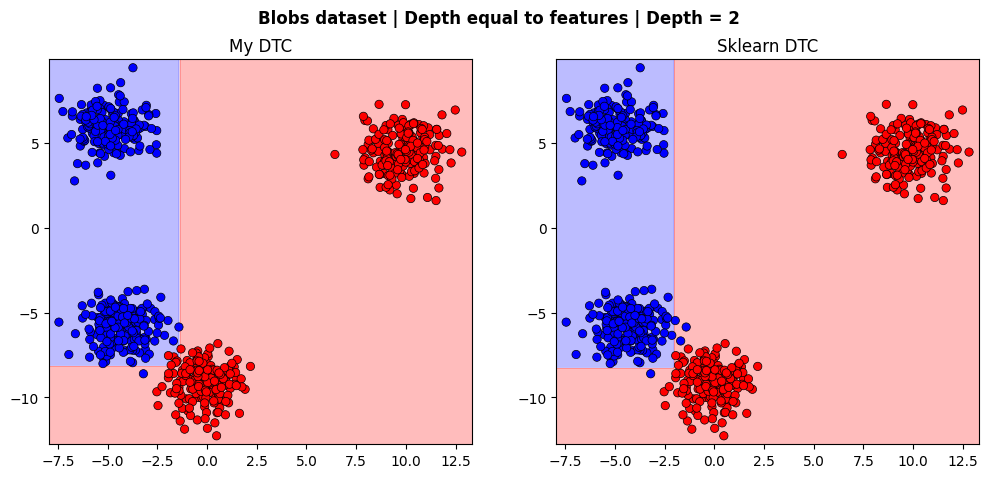

____________________________________

── My DTC for depth 4  ──
Confusion matrix:
[[394   2]
 [  2 393]]
Accuracy:       0.9949431099873578
Recall:         0.9949367088607595
Specificity:    0.9949494949494949

── Sklearn DTC for depth 4 ──
Confusion matrix:
[[394   2]
 [  0 395]]
Accuracy:       0.9974715549936789
Recall:         1.0
Specificity:    0.9949494949494949


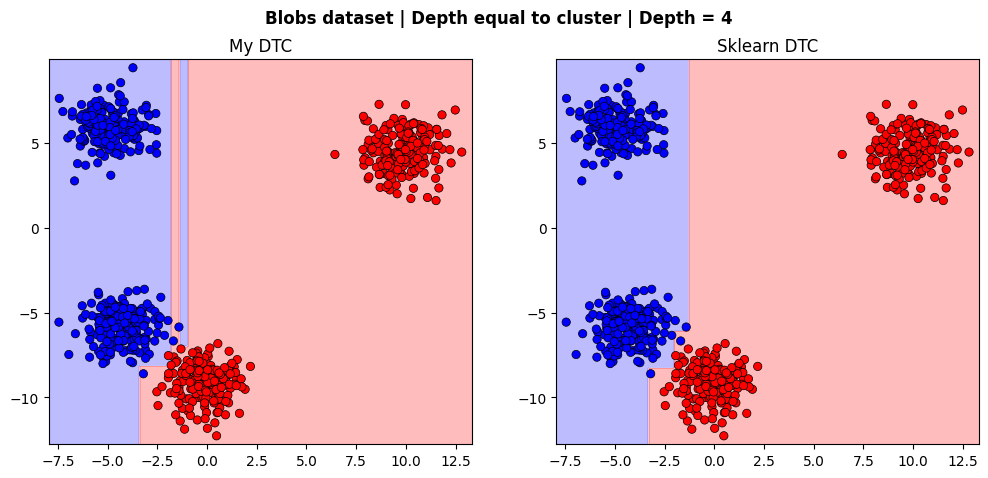

In [255]:
my_dtc = DecisionTree(5)
sk_dtc = DecisionTreeClassifier(max_depth=5)

X_train_blobs, X_test_blobs, y_train_blobs, y_test_blobs = train_test_split(
    X_multi_claster, y_multi_claster, test_size=0.3, random_state=RANDOM_STATE, stratify=y_multi_claster)

n_features = X_multi_claster.shape[1]
n_cluster = 4
depths_to_test = [None, n_features, n_cluster] # ulimited, number of features, total number of clusters
titles = ["Unlimited depth", "Depth equal to features", "Depth equal to cluster"]

for depth, title in zip(depths_to_test, titles):
    print("____________________________________")
    my_dtc = DecisionTree(depth)
    sk_dtc = DecisionTreeClassifier(max_depth=depth, criterion="entropy")

    my_dtc.fit(X_train_blobs, y_train_blobs)
    sk_dtc.fit(X_train_blobs, y_train_blobs)

    print_metrics(my_dtc, X_test_blobs, y_test_blobs, f"My DTC for depth {depth} ")
    print_metrics(sk_dtc, X_test_blobs, y_test_blobs, f"Sklearn DTC for depth {depth}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"Blobs dataset | {title} | Depth = {depth}", fontweight="bold")
    plot_decision_boundary(my_dtc, X_test_blobs, y_test_blobs, axes[0], "My DTC")
    plot_decision_boundary(sk_dtc, X_test_blobs, y_test_blobs, axes[1], "Sklearn DTC")
    plt.show()

_____________

# Testing sklearn DTC on real data

## Importing dataset

In [256]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
htru2 = fetch_ucirepo(id=372) 
  
# data (as pandas dataframes) 
X = htru2.data.features 
y = htru2.data.targets 
  
# metadata 
print(htru2.metadata) 
  
# variable information 
print(htru2.variables) 

{'uci_id': 372, 'name': 'HTRU2', 'repository_url': 'https://archive.ics.uci.edu/dataset/372/htru2', 'data_url': 'https://archive.ics.uci.edu/static/public/372/data.csv', 'abstract': 'Pulsar candidates collected during the HTRU survey. Pulsars are a type of star, of considerable scientific interest. Candidates must be classified in to pulsar and non-pulsar classes to aid discovery.', 'area': 'Physics and Chemistry', 'tasks': ['Classification', 'Clustering'], 'characteristics': ['Multivariate'], 'num_instances': 17898, 'num_features': 8, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2015, 'last_updated': 'Wed Apr 03 2024', 'dataset_doi': '10.24432/C5DK6R', 'creators': ['Robert Lyon'], 'intro_paper': {'ID': 460, 'type': 'NATIVE', 'title': 'Fifty years of pulsar candidate selection: from simple filters to a new principled real-time classification approach', 'a

In [257]:
np.unique(y)

array([0, 1])

In [258]:
print(len(y))
y.value_counts() # These counts suggest imbalanced dataset (1:16)

17898


class
0        16259
1         1639
Name: count, dtype: int64

In [259]:
X.head(2)

,Profile_mean,Profile_stdev,Profile_skewness,Profile_kurtosis,DM_mean,DM_stdev,DM_skewness,DM_kurtosis
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580


In [260]:
X.describe()

,Profile_mean,Profile_stdev,Profile_skewness,Profile_kurtosis,DM_mean,DM_stdev,DM_skewness,DM_kurtosis
count,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000
mean,111.079968,46.549532,0.477857,1.770279,12.614400,26.326515,8.303556,104.857709
std,25.652935,6.843189,1.064040,6.167913,29.472897,19.470572,4.506092,106.514540
min,5.812500,24.772042,-1.876011,-1.791886,0.213211,7.370432,-3.139270,-1.976976
25%,100.929688,42.376018,0.027098,-0.188572,1.923077,14.437332,5.781506,34.960504
50%,115.078125,46.947479,0.223240,0.198710,2.801839,18.461316,8.433515,83.064556
75%,127.085938,51.023202,0.473325,0.927783,5.464256,28.428104,10.702959,139.309330
max,192.617188,98.778911,8.069522,68.101622,223.392141,110.642211,34.539844,1191.000837


In [261]:
X.isna().sum()

Profile_mean        0
Profile_stdev       0
Profile_skewness    0
Profile_kurtosis    0
DM_mean             0
DM_stdev            0
DM_skewness         0
DM_kurtosis         0
dtype: int64

## Data preprocessing

No need to preprocess features (no missing values, normalization does nothing for dtc)

classes need potential precprocessing because of imbalance


── my metrics ──
Confusion matrix:
[[4802   76]
 [  88  404]]
Accuracy:       0.9694599627560522
Recall:         0.8211382113821138
Specificity:    0.984419844198442


              precision    recall  f1-score   support

           0       0.98      0.98      0.98      4878
           1       0.84      0.82      0.83       492

    accuracy                           0.97      5370
   macro avg       0.91      0.90      0.91      5370
weighted avg       0.97      0.97      0.97      5370



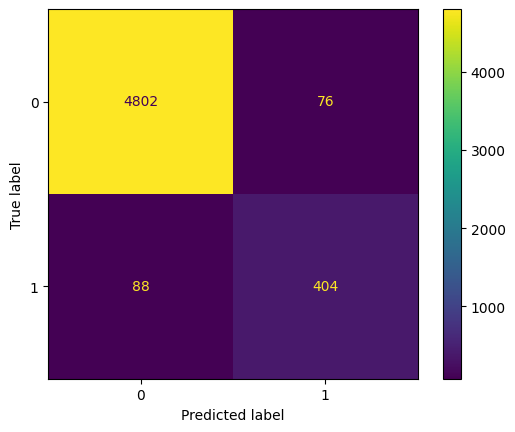

In [262]:
# Test before preprocessing:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)

dtc = DecisionTreeClassifier(criterion='entropy')
dtc.fit(X_train, y_train)

print_metrics(dtc, X_test, y_test, "my metrics")
print("\n")
print(classification_report(y_pred=dtc.predict(X_test), y_true=y_test))

ConfusionMatrixDisplay.from_estimator(dtc, X_test, y_test)
plt.show()

preprocessing

class
0        11381
1        11381
Name: count, dtype: int64

── my metrics ──
Confusion matrix:
[[11381     0]
 [ 1154 10227]]
Accuracy:       0.9493014673578771
Recall:         0.8986029347157544
Specificity:    1.0


              precision    recall  f1-score   support

           0       0.98      0.99      0.98      4878
           1       0.85      0.82      0.83       492

    accuracy                           0.97      5370
   macro avg       0.92      0.90      0.91      5370
weighted avg       0.97      0.97      0.97      5370



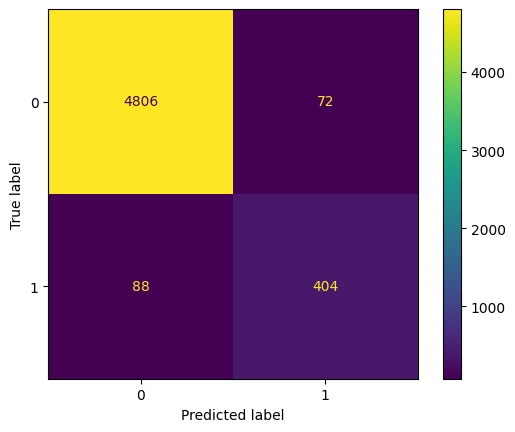

In [263]:
# Oversampling
from imblearn.over_sampling import SMOTE, RandomOverSampler, ADASYN

over_sampler = SMOTE()

X_resampled, y_resampled = over_sampler.fit_resample(X=X_train, y=y_train)
print(y_resampled.value_counts())

dtc = DecisionTreeClassifier(criterion='entropy')
dtc.fit(X_train, y_train)

print_metrics(dtc, X_resampled, y_resampled, "my metrics")
print("\n")
print(classification_report(y_pred=dtc.predict(X_test), y_true=y_test))

ConfusionMatrixDisplay.from_estimator(dtc, X_test, y_test)
plt.show()

# Training and testing on real data

In [264]:
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline

In [265]:
train_samples, train_features = X.shape
depths = [x for x in range(1, 30)]
min_samples_split = [2, 5, 10, 20, 50, 0.01]
min_samples_leaf = [1, 2, 5, 10, 20, 0.01]

param_grid = {
    'criterion': ['entropy', 'gini', 'log_loss'],
    'max_depth': [None] + depths,
    'min_samples_split': min_samples_split,
    'min_samples_leaf': min_samples_leaf
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(),
    param_grid,
    n_jobs = -1,
    scoring='recall',
)

grid_search.fit(X_resampled, y_resampled)
# grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['entropy', 'gini', ...], 'max_depth': [None, 1, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold 

Best params: {'criterion': 'log_loss', 'max_depth': 23, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best recall: 0.9711

── Best DTC ──
Confusion matrix:
[[4690  188]
 [  73  419]]
Accuracy:       0.9513966480446927
Recall:         0.8516260162601627
Specificity:    0.9614596145961459
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      4878
           1       0.85      0.82      0.83       492

    accuracy                           0.97      5370
   macro avg       0.92      0.90      0.91      5370
weighted avg       0.97      0.97      0.97      5370



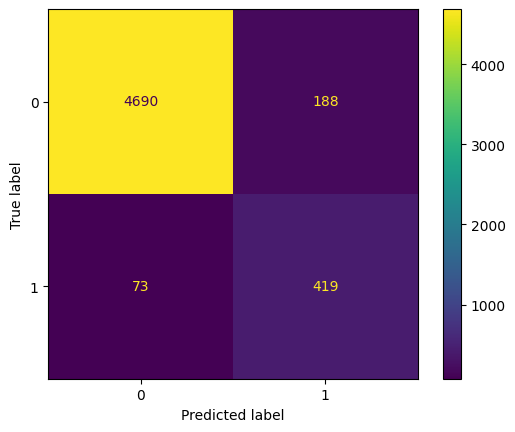

In [266]:
print(f"Best params: {grid_search.best_params_}")
print(f"Best recall: {grid_search.best_score_:.4f}")

best_dtc = grid_search.best_estimator_

print_metrics(best_dtc, X_test, y_test, "Best DTC")
print(classification_report(y_pred=dtc.predict(X_test), y_true=y_test))

ConfusionMatrixDisplay.from_estimator(best_dtc, X_test, y_test)
plt.show()

____________

# Depth impact analysis

In [267]:
import time
from tqdm import tqdm

In [268]:
depths = [x for x in range(1, 30)] + [None]

results = {
    # depth :
    #     sk_train_time: time 
    #     my_train_time: time 
    #     sk_recall_score: score 
    #     my_recall_score: score
}

In [276]:
for depth in tqdm(depths):
    sk_train_times = []
    my_train_times = []
    sk_infer_times = []
    my_infer_times = []
    sk_f1_scores = []
    my_f1_scores = []

    for _ in range(10):
        # --- SKLEARN MODEL ---
        sk_model = DecisionTreeClassifier(max_depth=depth, criterion='entropy')

        t0 = time.perf_counter()
        sk_model.fit(X_resampled.to_numpy(), y_resampled.to_numpy().flatten())
        sk_train_times.append(time.perf_counter() - t0)

        t0 = time.perf_counter()
        sk_pred = sk_model.predict(X_test.to_numpy())
        sk_infer_times.append(time.perf_counter() - t0)

        sk_f1_scores.append(recall_score(y_test, sk_pred))


        # --- MY MODEL ---
        my_model = DecisionTree(max_depth=depth)
        t0 = time.perf_counter()
        my_model.fit(X_resampled.to_numpy(), y_resampled.to_numpy().flatten())
        my_train_times.append(time.perf_counter() - t0)

        t0 = time.perf_counter()
        my_pred = my_model.predict(X_test.to_numpy())
        my_infer_times.append(time.perf_counter() - t0)

        my_f1_scores.append(recall_score(y_test, my_pred))

    results[depth] = {
        "sk_train_time": np.mean(sk_train_times),
        "my_train_time": np.mean(my_train_times),
        "sk_infer_time": np.mean(sk_infer_times),
        "my_infer_time": np.mean(my_infer_times),
        "sk_recall_score": np.mean(sk_f1_scores),
        "my_recall_score": np.mean(my_f1_scores),
    }

100%|██████████| 30/30 [15:20<00:00, 30.67s/it]


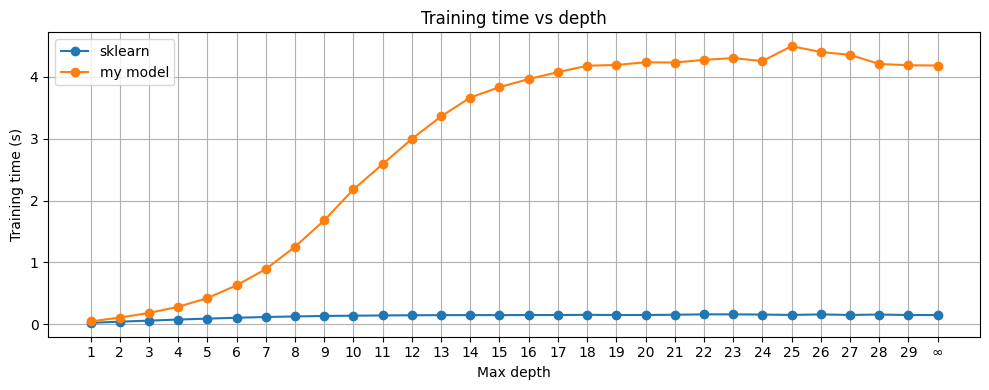

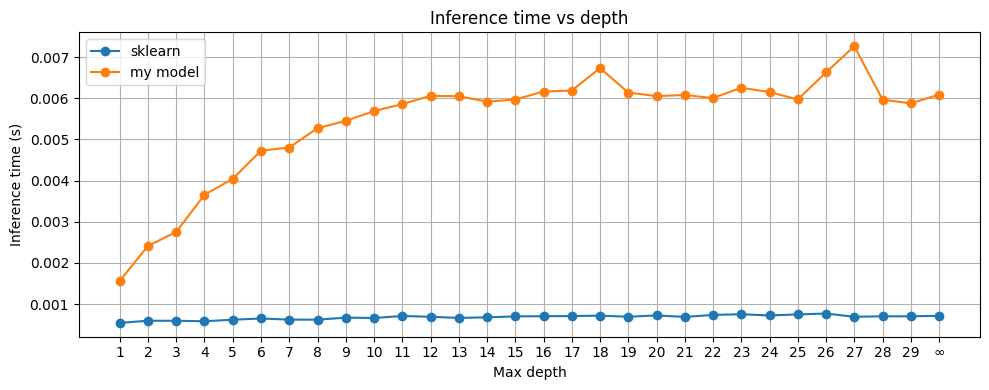

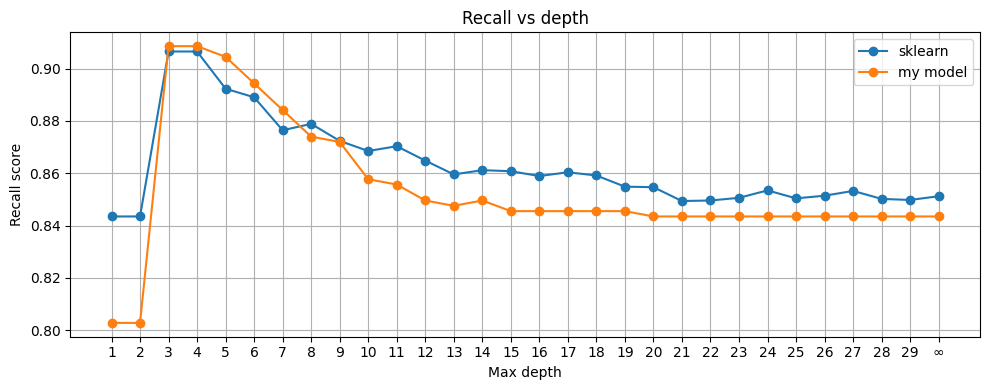

In [277]:
finite_depths = sorted(d for d in results.keys() if d is not None)
depths_list = finite_depths + [None]

x_positions = list(range(len(depths_list)))
x_labels = [str(d) for d in finite_depths] + ["∞"]

sk_train = [results[d]["sk_train_time"] for d in depths_list]
my_train = [results[d]["my_train_time"] for d in depths_list]

sk_infer = [results[d]["sk_infer_time"] for d in depths_list]
my_infer = [results[d]["my_infer_time"] for d in depths_list]

sk_recall = [results[d]["sk_recall_score"] for d in depths_list]
my_recall = [results[d]["my_recall_score"] for d in depths_list]

plt.figure(figsize=(10, 4))
plt.plot(x_positions, sk_train, marker='o', label='sklearn')
plt.plot(x_positions, my_train, marker='o', label='my model')
plt.xticks(x_positions, x_labels)
plt.xlabel("Max depth")
plt.ylabel("Training time (s)")
plt.title("Training time vs depth")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(x_positions, sk_infer, marker='o', label='sklearn')
plt.plot(x_positions, my_infer, marker='o', label='my model')
plt.xticks(x_positions, x_labels)
plt.xlabel("Max depth")
plt.ylabel("Inference time (s)")
plt.title("Inference time vs depth")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(x_positions, sk_recall, marker='o', label='sklearn')
plt.plot(x_positions, my_recall, marker='o', label='my model')
plt.xticks(x_positions, x_labels)
plt.xlabel("Max depth")
plt.ylabel("Recall score")
plt.title("Recall vs depth")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

__________

# Conclusions